In [4]:
# data -> salary_Data.csv

In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [7]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
# check for linearity

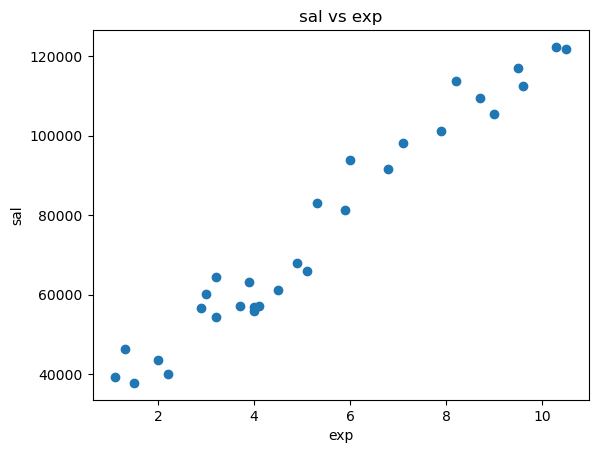

In [10]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);

In [11]:
x = df[['YearsExperience']]
y = df['Salary']

In [12]:
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [13]:
# cross val

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train, y_test = train_test_split(x,y, random_state=0,test_size= 0.25)

In [15]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((22, 1), (22,), (8, 1), (8,))

In [16]:
# build the model

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# val of m
lr.coef_

array([9379.71049195])

In [19]:
# val of c
lr.intercept_

np.float64(26986.691316737248)

In [20]:
# compare act and pred

In [21]:
y_pred = lr.predict(x_test)

In [22]:
pd.DataFrame({'actual': y_test,
              'pred': y_pred})

,actual,pred
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [23]:
# plot the best fit line on the previous scatter chart

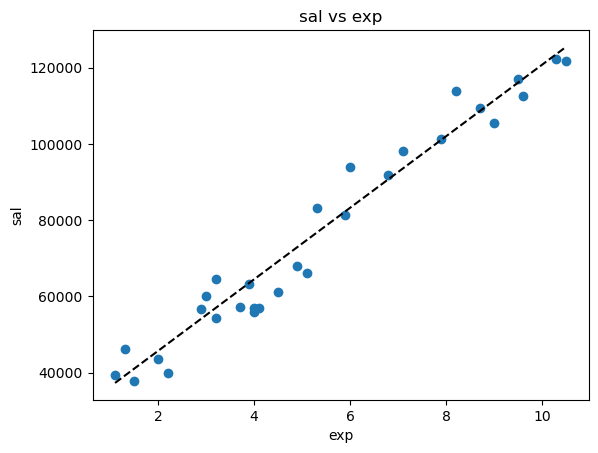

In [24]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x , lr.predict(x), color='black', ls = '--');

In [25]:
from sklearn.metrics import  mean_absolute_error

In [26]:
mean_absolute_error(y_test, y_pred)

3508.5455930660555

In [27]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9779208335417602

In [28]:
#polynomial reg

In [29]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [30]:
 # create polynomal features

In [31]:
from sklearn.preprocessing import PolynomialFeatures

In [32]:
poly = PolynomialFeatures(degree=3)

In [33]:
x_poly = poly.fit_transform(x)

In [34]:
x_poly
# cross val, linear reg model, r2 score

array([[1.000000e+00, 1.100000e+00, 1.210000e+00, 1.331000e+00],
       [1.000000e+00, 1.300000e+00, 1.690000e+00, 2.197000e+00],
       [1.000000e+00, 1.500000e+00, 2.250000e+00, 3.375000e+00],
       [1.000000e+00, 2.000000e+00, 4.000000e+00, 8.000000e+00],
       [1.000000e+00, 2.200000e+00, 4.840000e+00, 1.064800e+01],
       [1.000000e+00, 2.900000e+00, 8.410000e+00, 2.438900e+01],
       [1.000000e+00, 3.000000e+00, 9.000000e+00, 2.700000e+01],
       [1.000000e+00, 3.200000e+00, 1.024000e+01, 3.276800e+01],
       [1.000000e+00, 3.200000e+00, 1.024000e+01, 3.276800e+01],
       [1.000000e+00, 3.700000e+00, 1.369000e+01, 5.065300e+01],
       [1.000000e+00, 3.900000e+00, 1.521000e+01, 5.931900e+01],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 4.100000e+00, 1.681000e+01, 6.892100e+01],
       [1.000000e+00, 4.500000e+00, 2.025000e+01, 9.112500e+01],
       [1.000000e+00, 4.9

In [35]:
x_train, x_test, y_train, y_test = train_test_split (x_poly , y, random_state=0)

In [36]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred = lr.predict(x_test)

In [38]:
r2_score(y_test, y_pred)

0.982079101977056

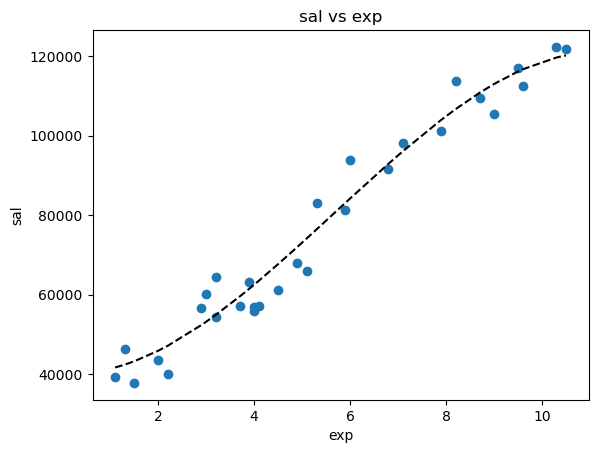

In [39]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x_poly), color = 'black', ls = '--');

In [40]:
# check for overfit

print("train:", lr.score(x_train, y_train))  # training acc
print("test:", lr.score(x_test, y_test)) # test acc

train: 0.9485797149704271
test: 0.982079101977056
